In [3]:
import pandas as pd

# load main tables
orders = pd.read_csv("data/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("data/raw/olist_order_payments_dataset.csv")
customers = pd.read_csv("data/raw/olist_customers_dataset.csv")
products = pd.read_csv("data/raw/olist_products_dataset.csv")
reviews = pd.read_csv("data/raw/olist_order_reviews_dataset.csv")

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

In [6]:
#checking for missing values
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [8]:
## Missing values in delivery-related fields indicate that not all orders were completed, suggesting the presence of canceled or ongoing orders.

In [9]:
delivered_orders = orders[orders['order_status'] == 'delivered']

In [13]:
df_revenue = payments.merge(delivered_orders, on='order_id')

df_revenue['payment_value'].sum()

df['order_id'].nunique()

df.shape
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,29.99,8.72,1,credit_card,1,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,29.99,8.72,3,voucher,1,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,29.99,8.72,2,voucher,1,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,118.70,22.76,1,boleto,1,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,159.90,19.22,1,credit_card,3,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


<Axes: title={'center': 'Monthly Revenue'}, xlabel='month'>

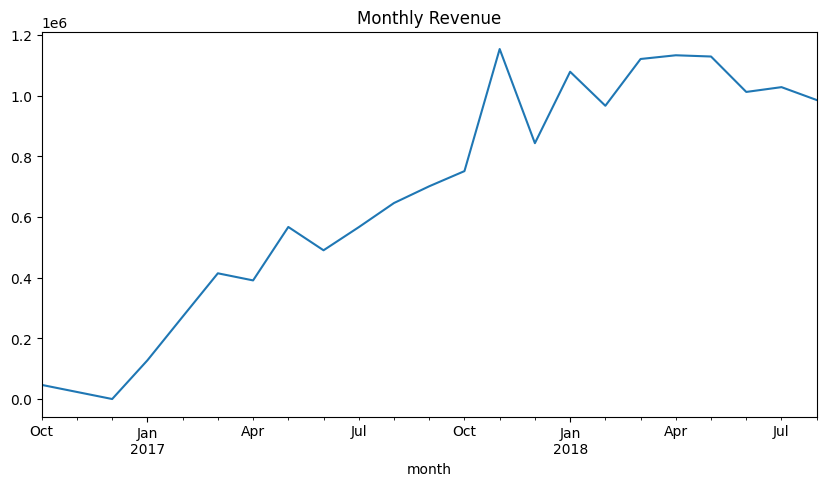

In [14]:
df_revenue['order_purchase_timestamp'] = pd.to_datetime(df_revenue['order_purchase_timestamp'])

df_revenue['month'] = df_revenue['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = df_revenue.groupby('month')['payment_value'].sum()

monthly_revenue.plot(figsize=(10,5), title='Monthly Revenue')

In [15]:
## Revenue trends show fluctuations over time, highlighting potential seasonal patterns in customer purchasing behavior.

In [16]:
#top 10 
df_revenue.groupby('customer_id')['payment_value'].sum().sort_values(ascending=False).head(10)

customer_id
1617b1357756262bfa56ab541c47bc16    13664.08
ec5b2ba62e574342386871631fafd3fc     7274.88
c6e2731c5b391845f6800c97401a43a9     6929.31
f48d464a0baaea338cb25f816991ab1f     6922.21
3fd6777bbce08a352fddd04e4a7cc8f6     6726.66
05455dfa7cd02f13d132aa7a6a9729c6     6081.54
df55c14d1476a9a3467f131269c2477f     4950.34
24bbf5fd2f2e1b359ee7de94defc4a15     4764.34
3d979689f636322c62418b6346b1c6d2     4681.78
1afc82cd60e303ef09b4ef9837c9505c     4513.32
Name: payment_value, dtype: float64

In [17]:
#order per month 
df_revenue.groupby('month')['order_id'].nunique()

month
2016-10     265
2016-12       1
2017-01     750
2017-02    1653
2017-03    2546
2017-04    2303
2017-05    3546
2017-06    3135
2017-07    3872
2017-08    4193
2017-09    4150
2017-10    4478
2017-11    7289
2017-12    5513
2018-01    7069
2018-02    6555
2018-03    7003
2018-04    6798
2018-05    6749
2018-06    6099
2018-07    6159
2018-08    6351
Freq: M, Name: order_id, dtype: int64

In [19]:
product_names = products[['product_id', 'product_category_name']]
df_products = df.merge(product_names, on='product_id')

In [21]:
#top 10 products by revenue
df_products.groupby('product_category_name')['payment_value'] \
    .sum().sort_values(ascending=False).head(10)

product_category_name
cama_mesa_banho           1692714.28
beleza_saude              1620684.04
informatica_acessorios    1549372.59
moveis_decoracao          1394466.93
relogios_presentes        1387362.45
esporte_lazer             1349446.93
utilidades_domesticas     1069787.97
automotivo                 833745.67
ferramentas_jardim         810614.93
cool_stuff                 744649.32
Name: payment_value, dtype: float64

In [22]:
## Certain product categories contribute disproportionately to total revenue, indicating strong customer demand concentration.

In [25]:
df_revenue.groupby('customer_id')['payment_value'].sum().mean()


np.float64(159.8563571628471)

<Axes: >

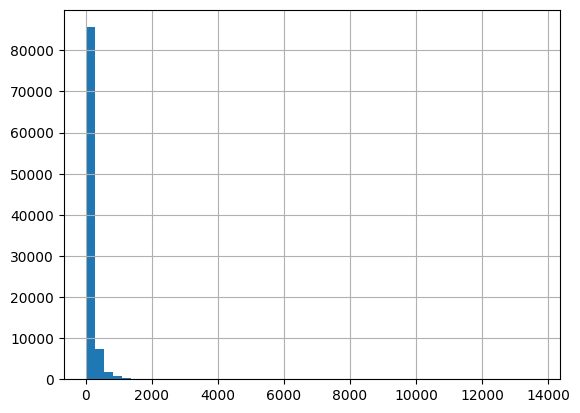

In [26]:
df_revenue.groupby('customer_id')['payment_value'].sum().hist(bins=50)

In [27]:
df_revenue['delivery_time'] = (
    df_revenue['order_delivered_customer_date'] - 
    df_revenue['order_purchase_timestamp']
).dt.days

In [31]:
#Average delivery time
round(df_revenue['delivery_time'].mean(), 2)

np.float64(12.11)

In [32]:
#The average delivery time is approximately 12 days, which reflects the logistics performance of the platform.

In [33]:
df_revenue['delivery_time'].describe()

count    100748.000000
mean         12.105888
std           9.554919
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_time, dtype: float64

<Axes: >

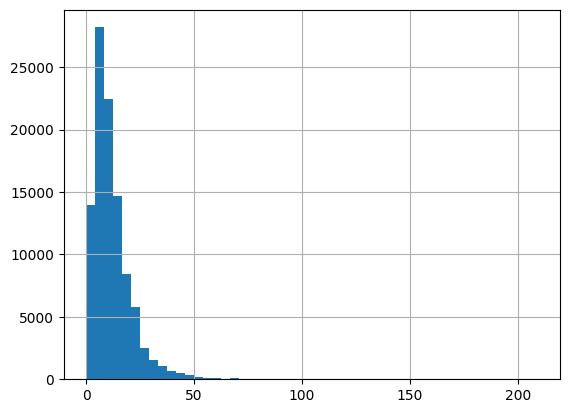

In [34]:
df_revenue['delivery_time'].hist(bins=50)

In [35]:
## The delivery time distribution is right-skewed, indicating that most orders are delivered within a short period, while a small number of orders experience significant delays.

In [38]:
df_full = df_revenue.merge(reviews, on='order_id')

df_full.groupby('review_score')['delivery_time'].mean()

review_score
1    20.796161
2    16.275784
3    13.762569
4    11.871372
5    10.236933
Name: delivery_time, dtype: float64

In [39]:
## Orders with lower review scores have longer average delivery times. One-star reviews averaged about 20.8 days, while five-star reviews averaged about 10.2 days, suggesting that delivery speed strongly affects customer satisfaction.

<Axes: title={'center': 'Average Delivery Time by Review Score'}, xlabel='Review Score', ylabel='Average Delivery Time (Days)'>

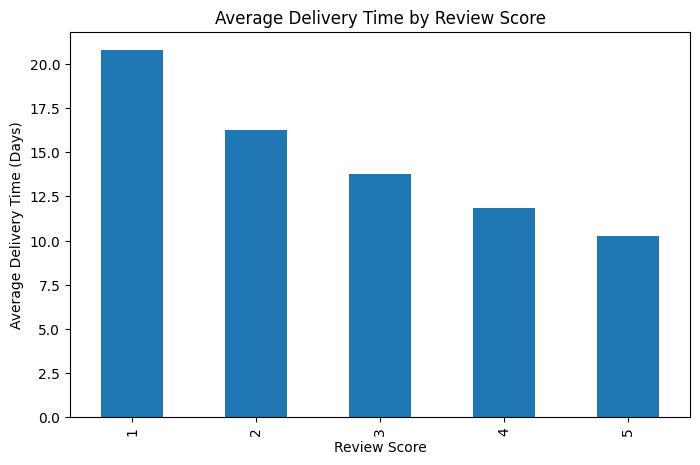

In [40]:
delivery_review = df_full.groupby('review_score')['delivery_time'].mean()

delivery_review.plot(
    kind='bar',
    figsize=(8,5),
    title='Average Delivery Time by Review Score',
    xlabel='Review Score',
    ylabel='Average Delivery Time (Days)'
)

In [43]:
revenue_table = df_revenue[['order_id', 'customer_id', 'payment_value', 'order_purchase_timestamp', 'delivery_time']]

revenue_table.to_csv("data/processed/revenue_table.csv", index=False)


In [44]:
monthly_revenue = df_revenue.groupby('month')['payment_value'].sum().reset_index()

monthly_revenue.to_csv("data/processed/monthly_revenue.csv", index=False)

In [45]:
orders_per_month = df_revenue.groupby('month')['order_id'].nunique().reset_index()

orders_per_month.to_csv("data/processed/orders_per_month.csv", index=False)

In [46]:
delivery_review = df_full.groupby('review_score')['delivery_time'].mean().reset_index()

delivery_review.to_csv("data/processed/delivery_vs_reviews.csv", index=False)

In [47]:
top_customers = df_revenue.groupby('customer_id')['payment_value'].sum().reset_index()

top_customers.to_csv("data/processed/top_customers.csv", index=False)